In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

In [3]:
X_train=np.loadtxt('dataset/input.csv', delimiter = ',')
Y_train=np.loadtxt('dataset/labels.csv', delimiter = ',')
X_test=np.loadtxt('dataset/input_test.csv', delimiter = ',')
Y_test=np.loadtxt('dataset/labels_test.csv', delimiter = ',')

In [4]:
X_train = X_train.reshape(len(X_train), 100, 100, 3)
Y_train = Y_train.reshape(len(Y_train), 1)

X_test = X_test.reshape(len(X_test), 100, 100, 3)
Y_test = Y_test.reshape(len(Y_test), 1)

X_train = X_train/255.0
X_test = X_test/255.0

In [5]:
print("Shape of X_train: ", X_train.shape)
print("Shape of Y_train: ", Y_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of Y_test: ", Y_test.shape)

Shape of X_train:  (2000, 100, 100, 3)
Shape of Y_train:  (2000, 1)
Shape of X_test:  (400, 100, 100, 3)
Shape of Y_test:  (400, 1)


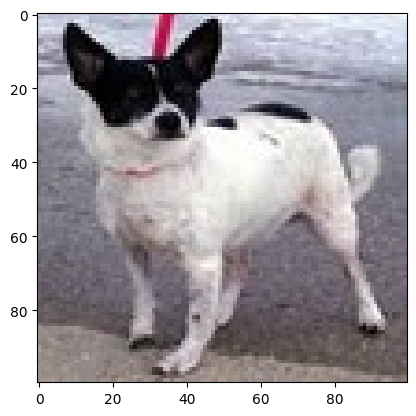

In [6]:
idx = random.randint(0, len(X_train))
plt.imshow(X_train[idx, :])
plt.show()

In [7]:
model=Sequential([
    Conv2D(32, (3,3), activation = 'relu', input_shape = (100, 100, 3)),
    MaxPooling2D((2,2)),
    
    Conv2D(32, (3,3), activation = 'relu'),
    MaxPooling2D((2,2)),
    
    Flatten(),
    Dense(64, activation = 'relu'),
    Dense(1, activation = 'sigmoid')
])

z:\Study Material\python 3.11\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    loss = 'binary_crossentropy',
    optimizer = 'adam', 
    metrics = ['accuracy'])

In [12]:
model.fit(X_train, Y_train, epochs = 5, batch_size = 64)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 371ms/step - accuracy: 0.8225 - loss: 0.3934
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 503ms/step - accuracy: 0.8610 - loss: 0.3236
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 427ms/step - accuracy: 0.8870 - loss: 0.2732
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 376ms/step - accuracy: 0.9260 - loss: 0.2013
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 493ms/step - accuracy: 0.9355 - loss: 0.1719


In [13]:
model.evaluate(X_test, Y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6600 - loss: 0.8226


[0.8225759267807007, 0.6600000262260437]

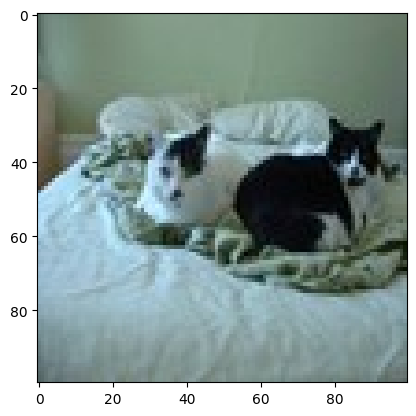

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Our model says it is a : cat


In [23]:
idx2 = random.randint(0, len(Y_test))
plt.imshow(X_test[idx2, :])
plt.show()

y_pred = model.predict(X_test[idx2, :].reshape(1, 100, 100, 3))
y_pred = y_pred > 0.5

if(y_pred == 0):
    pred = 'dog'
else:
    pred = 'cat'
    
print("Our model says it is a :", pred)